## Environment Setup (Chunk & Embed)

### Purpose
Prepares the environment for chunking transcripts and generating embeddings.

### Environment Variables
Loads the `.env` file and retrieves:
- `OPENAI_API_KEY`
- `PINECONE_API_KEY`

Both keys are validated to ensure the pipeline can continue.

### Client Initialization
Creates:
- An OpenAI client for embedding generation  
- A Pinecone client for vector database operations

### Result
Confirms that all services are ready for chunking and embedding tasks.


In [17]:
import os
from dotenv import load_dotenv
from openai import OpenAI
from pinecone import Pinecone

# ============================================================
# Cell 1 — Environment Setup
#
# Responsibilities:
# - Load environment variables
# - Validate required API keys
# - Initialize OpenAI and Pinecone clients
# ============================================================

ENV_PATH = "../.env"

if os.path.exists(ENV_PATH):
    load_dotenv(ENV_PATH)
    print("✅ Environment variables loaded.")
else:
    load_dotenv()
    print("⚠️ Using default environment.")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY not found.")

if not PINECONE_API_KEY:
    raise ValueError("PINECONE_API_KEY not found.")

client = OpenAI(api_key=OPENAI_API_KEY)
pc = Pinecone(api_key=PINECONE_API_KEY)

print("🚀 OpenAI and Pinecone clients initialized.")

✅ Environment variables loaded.
🚀 OpenAI and Pinecone clients initialized.


## Load Pipeline State (Chunk & Embed)

### Session State
Reads `session_state.json` to recover the `active_video_id` produced in previous notebooks.  
Ensures the file exists and the ID is valid.

### Transcript Path
Builds the path to the transcript file (`VIDEO_ID.txt`) inside `../data/`.

### Validation
Checks that the transcript file exists before continuing.  
If missing, the pipeline stops and instructs the user to rerun transcription.

### Result
Confirms the active video ID and verifies that the transcript is ready for chunking and embedding.


In [18]:
import json
import os

# ============================================================
# Cell 2 — Load Pipeline State
#
# Responsibilities:
# - Read session_state.json
# - Resolve active_video_id
# - Build transcript path
# - Verify transcript exists
# ============================================================

STATE_PATH = "../data/session_state.json"

if not os.path.exists(STATE_PATH):
    raise FileNotFoundError(
        "session_state.json not found. Run Notebook 1 and Notebook 2 first."
    )

with open(STATE_PATH, "r", encoding="utf-8") as f:
    session_state = json.load(f)

VIDEO_ID = session_state.get("active_video_id")

if not VIDEO_ID:
    raise ValueError("active_video_id not found in session_state.json")

TXT_INPUT_PATH = os.path.join("../data", f"{VIDEO_ID}.txt")

if not os.path.exists(TXT_INPUT_PATH):
    raise FileNotFoundError(
        f"Transcript not found: {TXT_INPUT_PATH}"
    )

print(f"🔄 Active Video ID: {VIDEO_ID}")
print(f"✅ Transcript loaded: {TXT_INPUT_PATH}")

🔄 Active Video ID: 4_oufjP2yeM
✅ Transcript loaded: ../data\4_oufjP2yeM.txt


## Chunking Engine with Metadata

### Purpose
Splits a timestamped transcript into structured text chunks while preserving contextual metadata for later embedding and retrieval.

### Timestamp Extraction
Uses a regex pattern to detect `[MM:SS]` timestamps and separate them from the spoken text.  
Each detected timestamp becomes the **anchor** for the chunk.

### Chunk Construction
Accumulates text until reaching the character limit (default: 800).  
Each chunk stores:
- The combined text  
- The anchor timestamp  
- The video ID  
- The character count  

### Overlap Logic
After flushing a chunk, keeps the last N words (default: 15) to maintain semantic continuity between chunks.

### Final Output
Returns a list of chunk dictionaries containing both text and metadata, ready for embedding and storage in Pinecone.


In [19]:
TIMESTAMP_PATTERN = re.compile(r"^\[([\d:]+)\]\s*(.*)$")


def chunk_transcript_with_timestamps(
    file_path,
    video_id,
    chunk_size_chars=800,
    overlap_words=15,
):
    """
    Splits a timestamped transcript into overlapping chunks.

    Each chunk keeps:
    - text
    - metadata (video_id, anchor timestamp, char_count)

    NOTE:
    Timestamp = anchor of chunk (first timestamp encountered).
    """

    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    chunks = []

    current_chunk_text = ""
    current_chunk_timestamp = None

    for line in lines:

        line = line.strip()

        if not line:
            continue

        match = TIMESTAMP_PATTERN.match(line)

        # -------------------------
        # Parse line
        # -------------------------
        if match:
            timestamp = f"[{match.group(1)}]"
            text = match.group(2)
        else:
            timestamp = None
            text = line

        # -------------------------
        # Set anchor timestamp
        # -------------------------
        if current_chunk_timestamp is None and timestamp:
            current_chunk_timestamp = timestamp

        # OPTIONAL FIX (important for correctness)
        # update anchor when a new timestamp appears
        if timestamp:
            current_chunk_timestamp = timestamp

        # -------------------------
        # Build chunk text
        # -------------------------
        current_chunk_text = f"{current_chunk_text} {text}".strip()

        # -------------------------
        # Flush chunk when size exceeded
        # -------------------------
        if len(current_chunk_text) >= chunk_size_chars:

            chunks.append(
                {
                    "text": current_chunk_text,
                    "metadata": {
                        "video_id": video_id,
                        "timestamp": current_chunk_timestamp or "[00:00]",
                        "char_count": len(current_chunk_text),
                    },
                }
            )

            # -------------------------
            # Overlap handling
            # -------------------------
            words = current_chunk_text.split()
            current_chunk_text = " ".join(words[-overlap_words:])

    # -------------------------
    # Flush last chunk
    # -------------------------
    if current_chunk_text:

        chunks.append(
            {
                "text": current_chunk_text,
                "metadata": {
                    "video_id": video_id,
                    "timestamp": current_chunk_timestamp or "[00:00]",
                    "char_count": len(current_chunk_text),
                },
            }
        )

    return chunks

## Generate Embeddings

### Chunk Processing
Runs the chunking engine to split the transcript into multiple timestamp‑anchored text chunks.  
Reports how many chunks were created.

### Embedding Generation
For each chunk:
- Sends the text to the `text-embedding-3-small` model  
- Receives a numerical embedding vector  
- Builds a unique vector ID (`VIDEO_ID_chunk_{idx}`)  
- Attaches metadata: `video_id`, `timestamp`, and the original text  

All vectors are collected into a list for later upsert into Pinecone.

### Error Handling
If any chunk fails to embed, the pipeline logs the issue but continues processing the remaining chunks.

### Result
Confirms how many vectors were successfully generated and prepared for insertion into the vector database.


In [20]:
# ============================================================
# Cell 4 — Generate Embeddings
#
# Responsibilities:
# - Split the transcript into chunks
# - Generate embeddings with OpenAI
# - Prepare vectors for Pinecone
# ============================================================

chunks = chunk_transcript_with_timestamps(
    TXT_INPUT_PATH,
    VIDEO_ID
)

print(f"📄 Transcript split into {len(chunks)} chunks.")
print("🧠 Generating embeddings...")

vectors_to_upsert = []

for idx, chunk in enumerate(chunks):

    try:

        response = client.embeddings.create(
            model="text-embedding-3-small",
            input=chunk["text"]
        )

        embedding = response.data[0].embedding

        vector_id = f"{VIDEO_ID}_chunk_{idx}"

        metadata = {
            "video_id": chunk["metadata"]["video_id"],
            "timestamp": chunk["metadata"]["timestamp"],
            "text": chunk["text"]
        }

        vectors_to_upsert.append(
            (
                vector_id,
                embedding,
                metadata
            )
        )

    except Exception as e:

        print(f"⚠️ Failed to process chunk {idx}: {e}")

print(f"✅ Generated {len(vectors_to_upsert)} vectors.")

📄 Transcript split into 18 chunks.
🧠 Generating embeddings...
✅ Generated 18 vectors.


In [26]:
def print_sample_chunks(chunks, sample_indices=[0, 1, 2]):
    """
    Print selected transcript chunks with timestamp (MM:SS) and text.
    Works with timestamps stored as strings like: "[00:40]".
    """

    for idx in sample_indices:
        chunk = chunks[idx]

        raw_ts = chunk["metadata"]["timestamp"]  # e.g. "[00:40]"

        # Remove brackets if present
        cleaned_ts = raw_ts.strip().strip("[]")  # "00:40"

        # Handle MM:SS format
        try:
            parts = cleaned_ts.split(":")
            if len(parts) == 2:
                minutes = int(parts[0])
                seconds = int(parts[1])
            elif len(parts) == 3:
                # If someday you have "HH:MM:SS"
                hours = int(parts[0])
                minutes = int(parts[1]) + hours * 60
                seconds = int(parts[2])
            else:
                raise ValueError("Unexpected timestamp format")

            pretty_ts = f"{minutes:02d}:{seconds:02d}"
        except Exception:
            print(f"Invalid timestamp format in chunk {idx}: {raw_ts}")
            continue

        text = chunk["text"].strip()

        print("=" * 80)
        print(f"Chunk #{idx}")
        print(f"Timestamp: {pretty_ts}  (original: {raw_ts})")
        print(f"Text:\n{text[:400]}...")
        print()




In [27]:
print_sample_chunks(chunks, sample_indices=[0, 1, 2])


Chunk #0
Timestamp: 00:40  (original: [00:40])
Text:
If the ATS can't read your resume, it will be rejected before a human ever sees it. I know because I was the former chief growth officer at WeWork where I read tens of thousands of resumes and personally hired thousands of people. Now I'm the founder of Teal, and I know firsthand how ATS systems actually work. Here's the truth about the ATS, exactly how to write a resume that beats it, and at the ...

Chunk #1
Timestamp: 01:19  (original: [01:19])
Text:
truth is, it's not a digital gatekeeper designed to control your fate and reject you. It's more like a workflow management system and a digital filing cabinet. Think of it like a database. There's actually a lot of misconception about the ATS that are affecting your job search. But since in this video, it's about beating the ATS, I'm going to break down all the myths in my next video. The ATS was ...

Chunk #2
Timestamp: 01:54  (original: [01:54])
Text:
and unfortunately, who's been r

Chunk #0
Timestamp: 00:40  (original: [00:40])
Text:
If the ATS can't read your resume, it will be rejected before a human ever sees it.

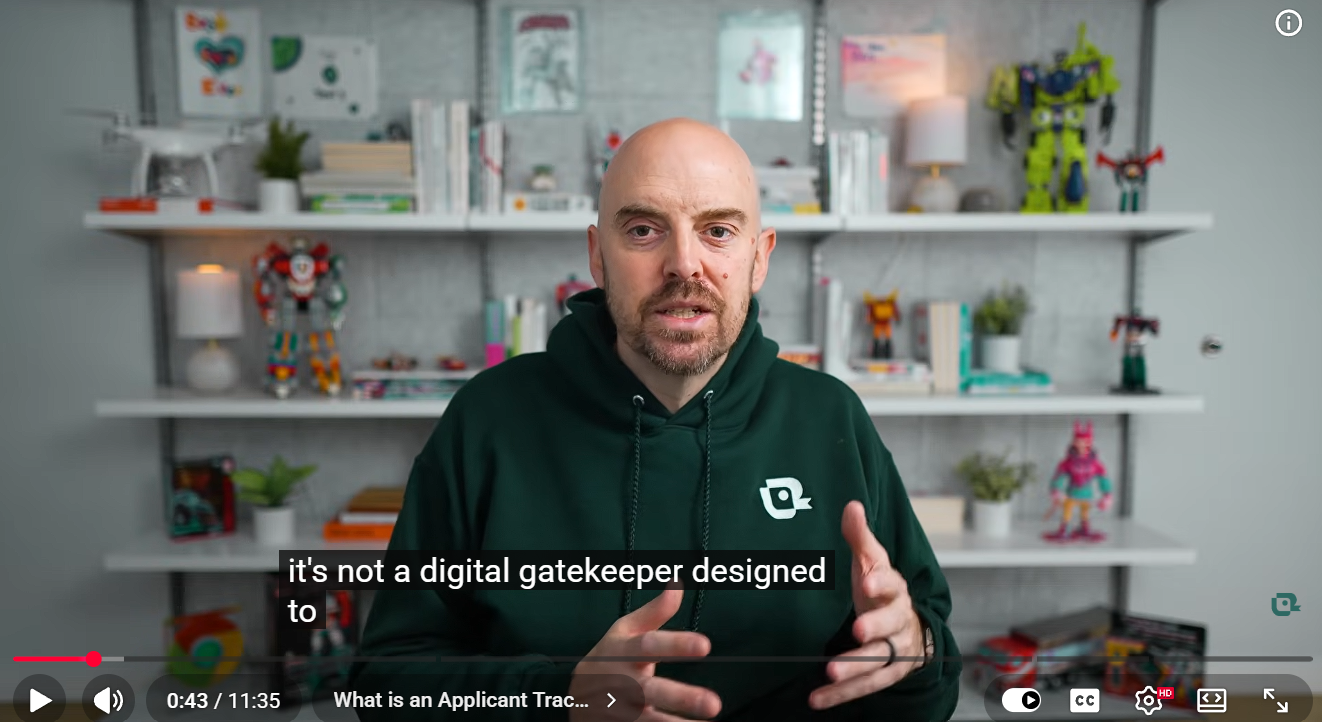

Chunk #1
Timestamp: 01:19  (original: [01:19])
Text:
truth is, it's not a digital gatekeeper designed to control your fate and reject you.
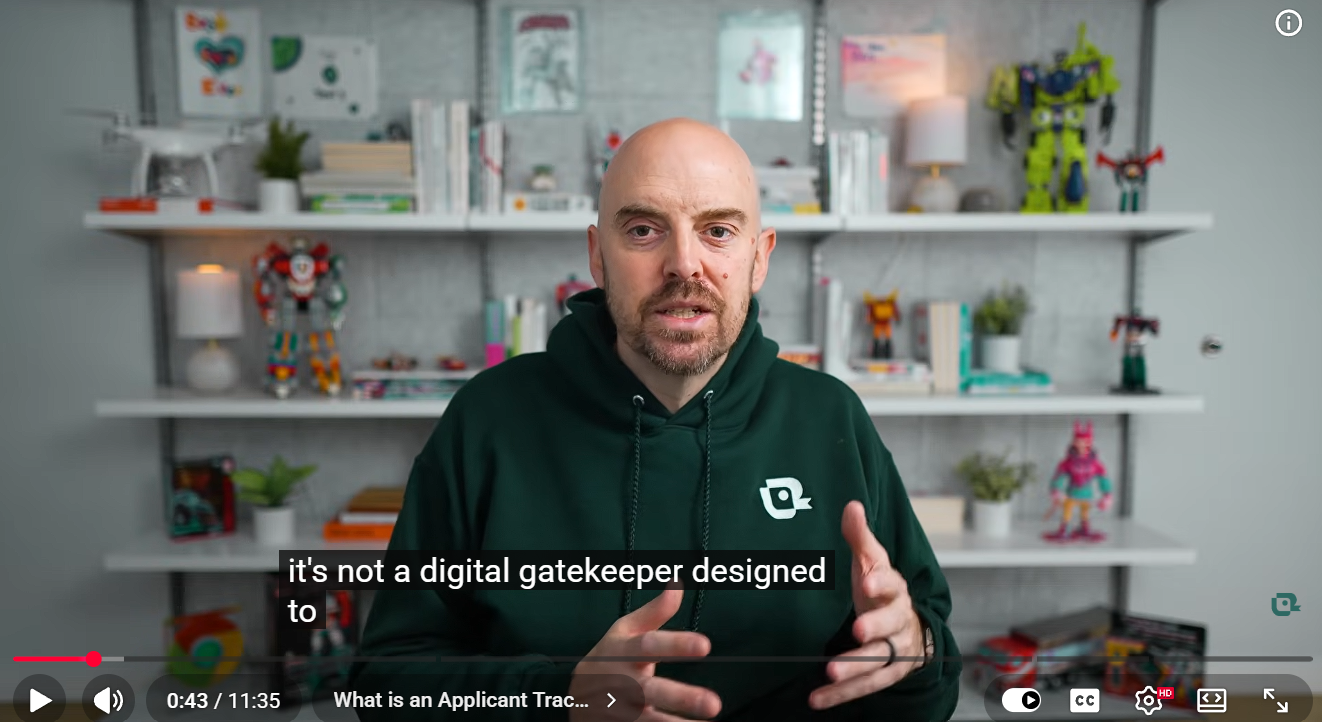

## Connect to Pinecone

### Index Resolution
Reads the `PINECONE_INDEX_NAME` from environment variables and validates that it exists.  
If the index name is missing or not found in Pinecone, the pipeline stops with a clear error.

### Index Verification
Retrieves the list of available Pinecone indexes and checks whether the configured one is present.

### Index Connection
Initializes a Pinecone `Index` object using the validated index name, enabling vector upsert and query operations.

### Result
Confirms a successful connection to the Pinecone index, preparing the pipeline for storing embeddings.


In [ ]:
# ============================================================
# Cell 5 — Connect to Pinecone
#
# Responsibilities:
# - Read Pinecone index name
# - Verify index exists
# - Connect to the Pinecone index
# ============================================================

INDEX_NAME = os.getenv("PINECONE_INDEX_NAME")

if not INDEX_NAME:
    raise ValueError("PINECONE_INDEX_NAME not found.")

available_indexes = [idx.name for idx in pc.list_indexes()]

if INDEX_NAME not in available_indexes:
    raise ValueError(
        f"Pinecone index '{INDEX_NAME}' not found.\n"
        f"Available indexes: {available_indexes}"
    )

index = pc.Index(INDEX_NAME)

print(f"✅ Connected to Pinecone index: {INDEX_NAME}")

✅ Connected to Pinecone index: resumazing-ironhack-final-proyect


## Upload Vectors to Pinecone

### Purpose
Stores all generated embeddings in Pinecone under a namespace matching the active video ID.  
This allows isolating vectors per video and simplifies later retrieval.

### Upload Process
Checks that vectors were successfully generated.  
Uses `index.upsert()` to insert:
- The vector ID  
- The embedding  
- The metadata (timestamp, text, video_id)

All vectors are uploaded into the namespace named after the video ID.

### Error Handling
If the upload fails, the pipeline raises a clear runtime error describing the issue.

### Result
Confirms how many vectors were indexed and completes the chunk‑and‑embed stage of the pipeline.


In [ ]:
# ============================================================
# Cell 6 — Upload Vectors to Pinecone
#
# Responsibilities:
# - Upload vectors to Pinecone
# - Store them in the active video namespace
# ============================================================

if not vectors_to_upsert:
    raise ValueError("No vectors available for upload.")

print(f"📤 Uploading {len(vectors_to_upsert)} vectors...")
print(f"📂 Namespace: {VIDEO_ID}")

try:

    response = index.upsert(
        vectors=vectors_to_upsert,
        namespace=VIDEO_ID
    )

    print(
        f"🎉 Upload completed successfully.\n"
        f"Vectors indexed: {response.upserted_count}"
    )

except Exception as e:

    raise RuntimeError(
        f"Failed to upload vectors to Pinecone: {e}"
    )

📤 Uploading 18 vectors...
📂 Namespace: 4_oufjP2yeM
🎉 Upload completed successfully.
Vectors indexed: 18


In [ ]:
stats = index.describe_index_stats()

print(stats)

{'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'4_oufjP2yeM': {'vector_count': 18}},
 'total_vector_count': 18,
 'vector_type': 'dense'}


## Vectors in Pinecone

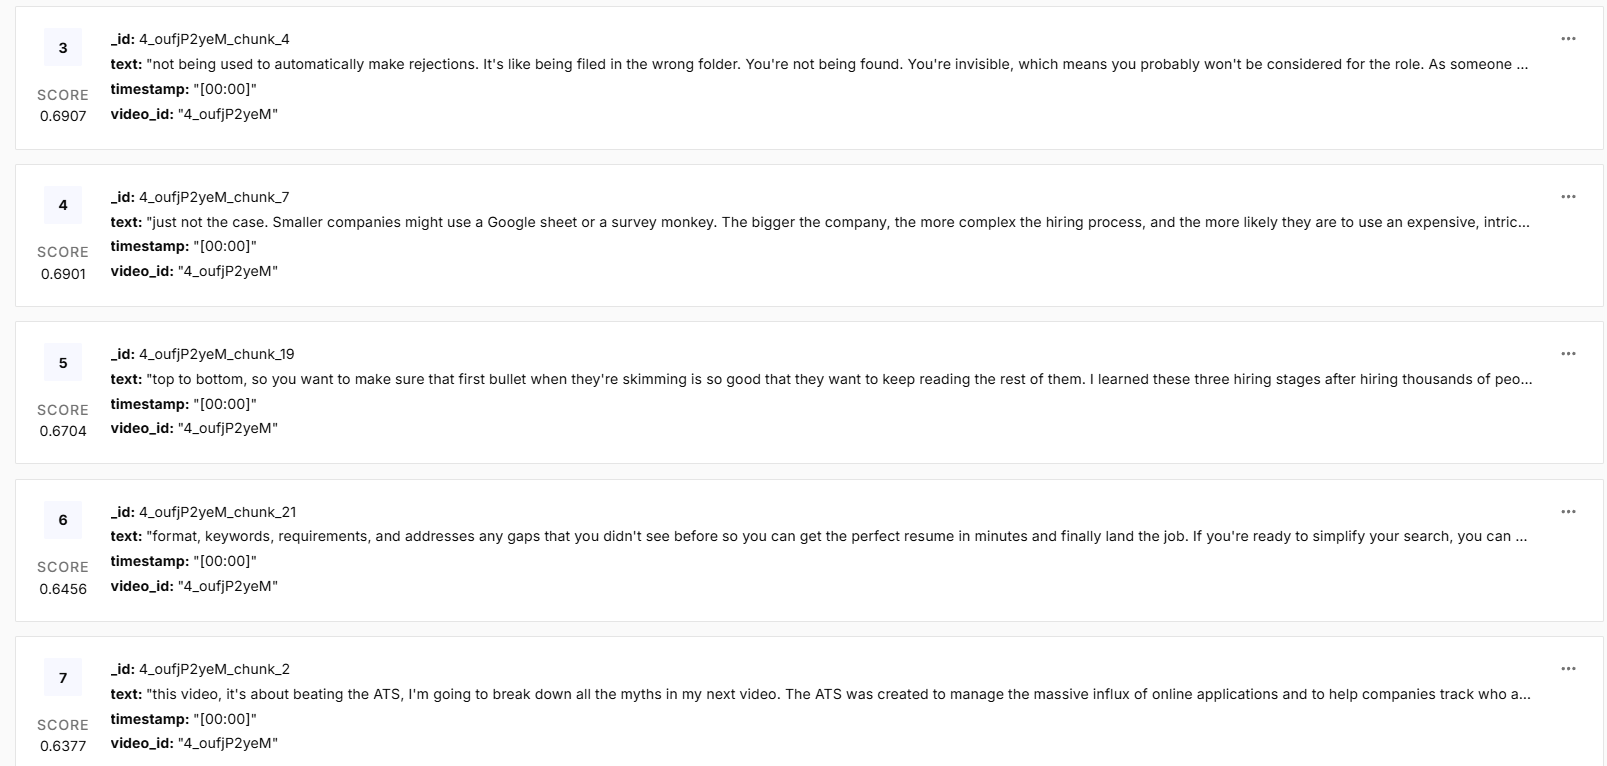


# Notebook 03 — Chunk & Embed Summary

This notebook takes the transcript produced in Notebook 02 and transforms it into vector embeddings stored in Pinecone, enabling semantic search and RAG.

## 1. Environment Setup
Loads `.env`, validates `OPENAI_API_KEY` and `PINECONE_API_KEY`, and initializes:
- OpenAI client (for embeddings)
- Pinecone client (for vector storage)

## 2. Pipeline State Loading
Reads `session_state.json` to recover the `active_video_id`.  
Builds the transcript path (`VIDEO_ID.txt`) and verifies the file exists.

## 3. Chunking Engine
Processes the transcript line‑by‑line, extracting timestamps and grouping text into chunks of ~800 characters.  
Each chunk includes:
- Text  
- Anchor timestamp  
- Video ID  
- Character count  
Chunks overlap by 15 words to preserve context.

## 4. Embedding Generation
For each chunk:
- Sends the text to `text-embedding-3-small`
- Receives an embedding vector
- Builds a unique vector ID
- Attaches metadata (timestamp, text, video_id)

All vectors are collected for upload.

## 5. Pinecone Index Connection
Reads the index name from environment variables.  
Verifies the index exists and connects to it.

## 6. Upload to Pinecone
Upserts all generated vectors into Pinecone under a namespace named after the video ID.  
Confirms how many vectors were successfully stored.

## Overall
This notebook converts the transcript into structured, timestamp‑aware chunks, embeds them using OpenAI, and stores them in Pinecone.  
It completes the preparation phase for retrieval‑augmented generation (RAG), enabling fast semantic search over the video content.
